# WUM 2026 — Project 1: Color Palette Reduction via Clustering

**Student index:** mg469284  


---

## Project Overview

This notebook solves the problem of **lossy image compression via color-palette reduction**.
The core idea is to represent every pixel in an image not by its exact RGB triplet
but by one of *k* cluster centroids — effectively reducing the palette from up to ~10 000 unique
colors to exactly *k* colors.

We work with a dataset of **132 PNG images** (55 cats, 77 flowers), each 100 × 100 pixels.

| Task | Description |
|------|-------------|
| 1 | Build `df_pixels` and `color_cats` DataFrames 
| 2 | Exploratory Data Analysis 
| 3 | KMeans vs KMedoids clustering, choose best k
| 4 | Save compressed images, measure gain, regression 
| 5 | kNN classification — original vs compressed

**Validation image:** `kotek-42.png`  



## Imports & Global Setup

To install required libraries run: **pip install -r requirements.txt**. Then run the next code window to set paths for output and image base in project folder.


In [1]:
import os
import warnings
import pickle
import colorsys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import to_hex
from pathlib import Path
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    pairwise_distances_argmin, f1_score, r2_score, make_scorer
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn_extra.cluster import KMedoids
from pathlib import Path



from IPython.display import Image as IPImage, display

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR = Path.cwd()
DATADIR = BASE_DIR / "kot-kwiat"
WORKSPACE = BASE_DIR / "data"
WORKSPACE.mkdir(parents=True, exist_ok=True)

print("Base dir:", BASE_DIR)
print("Image directory:", DATADIR)
print("Workspace:", WORKSPACE)


Base dir: /home/students/inf/m/mg469284/Pulpit/WUM_1
Image directory: /home/students/inf/m/mg469284/Pulpit/WUM_1/kot-kwiat
Workspace: /home/students/inf/m/mg469284/Pulpit/WUM_1/data


---
## Task 1 — Building the DataFrames

Two DataFrames are constructed from the 132 source images:

| DataFrame | Rows | Columns | Description |
|-----------|------|---------|-------------|
| `df_pixels` | 1 320 000 | 10 | One row per pixel: filename, category, x/y position, R, G, B, H, S, L |
| `color_stats` | 848 248 | 13 | One row per unique (R, G, B) triplet across the whole dataset + flags |

Each image is 100 × 100 px → 10 000 pixels per image → 132 × 10 000 = **1 320 000 rows**.

HSL channels are derived from RGB with Python's `colorsys` module.
The `color_stats` DataFrame also stores two binary flags per color:
- `is_cool` — 1 if the hue indicates a *cool* color (H ∈ [150°, 330°])
- `is_staurated` — 1 if saturation > 50 %

## DataFrames used in the analysis

### 1. `df_pixels`

The `df_pixels` DataFrame contains one row per pixel. It stores the image identifier, the pixel position, and the full color description in both RGB and HSL space.

| Column | Meaning |
|---|---|
| `filename` | Original image filename  |
| `category` | Image class (`cat` or `flower`) |
| `x` | Horizontal pixel coordinate | 
| `y` | Vertical pixel coordinate |
| `R` | Red channel in RGB |
| `G` | Green channel in RGB |
| `B` | Blue channel in RGB |
| `H` | Hue in HSL |
| `S` | Saturation in HSL |
| `L` | Lightness in HSL |

### 2. `color_stats`

The `color_stats` DataFrame contains one row for each unique RGB color observed in the dataset. In addition to the color itself, it stores the number of occurrences in cat images and flower images, as well as binary indicators derived from the RGB and HSL definitions required in the assignment.]

| Column | Meaning |
|---|---|
| `R` | Red channel of the unique color|
| `G` | Green channel of the unique color|
| `B` | Blue channel of the unique color|
| `H` | Hue corresponding to the color|
| `S` | Saturation corresponding to the color|
| `L` | Lightness corresponding to the color|
| `count_cat` | Number of times the color appears in cat images|
| `count_flower` | Number of times the color appears in flower images|
| `dom_R` | Binary flag indicating whether the red component is dominant|
| `dom_G` | Binary flag indicating whether the green component is dominant|
| `dom_B` | Binary flag indicating whether the blue component is dominant|
| `czy_zimny` | Binary flag equal to 1 if $H \in [180, 270]$|
| `czy_nasycony` | Binary flag equal to 1 if \(S > 70\%\)| 


---

### a) Build the `df_pixels` dataset

This cell creates the main pixel-level dataset used in the project.
Image-level DataFrames are concatenated into one large table called `df_pixels`, which is then saved as a CSV file in `data` for later use.

In [2]:
def get_category(filename: str) -> str:
    if filename.startswith("kotek-"):
        return "cat"
    elif filename.startswith("kwiatek-"):
        return "flower"
    else:
        return "unknown"

def image_to_df(img_path: Path) -> pd.DataFrame:
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)

    h, w, _ = arr.shape
    yy, xx = np.indices((h, w))

    flat_rgb = arr.reshape(-1, 3)
    flat_x = xx.reshape(-1)
    flat_y = yy.reshape(-1)

    rgb_norm = flat_rgb / 255.0
    hls = np.array([colorsys.rgb_to_hls(r, g, b) for r, g, b in rgb_norm])

    H = hls[:, 0] * 360.0
    L = hls[:, 1] * 100.0
    S = hls[:, 2] * 100.0

    df = pd.DataFrame({
        "filename": img_path.name,
        "category": get_category(img_path.name),
        "x": flat_x.astype(np.int16),
        "y": flat_y.astype(np.int16),
        "R": flat_rgb[:, 0].astype(np.uint8),
        "G": flat_rgb[:, 1].astype(np.uint8),
        "B": flat_rgb[:, 2].astype(np.uint8),
        "H": H.astype(np.float32),
        "S": S.astype(np.float32),
        "L": L.astype(np.float32),
    })
    return df

image_files = sorted(DATADIR.glob("*.png"))
df_pixels = pd.concat([image_to_df(p) for p in image_files], ignore_index=True)



df_pixels.to_csv(WORKSPACE / "df_pixels.csv", index=False)


print(df_pixels.shape)

(1320000, 10)


### b) Build the `color_stats` dataset

This cell creates a color-level summary dataset where each row represents one unique RGB triplet.
The resulting dataset is saved as `color_stats.csv` in `data` folder for later analysis.

In [3]:
color_stats = (
    df_pixels
    .groupby(["R", "G", "B"], as_index=False)
    .agg(
        H=("H", "first"),
        S=("S", "first"),
        L=("L", "first"),
        count_cat=("category", lambda x: (x == "cat").sum()),
        count_flower=("category", lambda x: (x == "flower").sum()),
    )
)

color_stats["dom_R"] = ((color_stats["R"] >= color_stats["G"]) & (color_stats["R"] >= color_stats["B"])).astype(np.uint8)
color_stats["dom_G"] = ((color_stats["G"] >= color_stats["R"]) & (color_stats["G"] >= color_stats["B"])).astype(np.uint8)
color_stats["dom_B"] = ((color_stats["B"] >= color_stats["R"]) & (color_stats["B"] >= color_stats["G"])).astype(np.uint8)

color_stats["is_cool"] = color_stats["H"].between(180, 270, inclusive="both").astype(np.uint8)
color_stats["is_saturated"] = (color_stats["S"] > 70).astype(np.uint8)

color_stats.to_csv(WORKSPACE / "color_stats.csv", index=False)

print(color_stats.shape)

(848248, 13)


## Check if everything loaded successfully ##
As I will be using those DataFrames extensively we have to make sure everything loaded correctly.

In [4]:
# ── Basic sanity checks ───────────────────────────────────────────────────
n_images = df_pixels['filename'].nunique()
n_cats   = (df_pixels['category'] == 'cat').sum() // 10_000
n_flow   = (df_pixels['category'] == 'flower').sum() // 10_000

print(f'Total images  : {n_images}  (expected 132)')
print(f'  Cats        : {n_cats}   (expected 55)')
print(f'  Flowers     : {n_flow}   (expected 77)')
print(f'Total pixels  : {len(df_pixels):,}  (expected 1,320,000)')
print(f'Unique colors : {len(color_stats):,}  (expected 848,248)')


Total images  : 132  (expected 132)
  Cats        : 55   (expected 55)
  Flowers     : 77   (expected 77)
Total pixels  : 1,320,000  (expected 1,320,000)
Unique colors : 848,248  (expected 848,248)


**Validate using cat no. 42 as specified (my index ends with 84)**

Now I will display chosen cat as the original image and as reconstruction based solely on prepared pixels data frame. It should be a pixel-perferct reconstruction. Cell output shows whether all pixels are the same as in the original picture version.

Pixel-perfect reconstruction: True  (all 30,000 values identical)


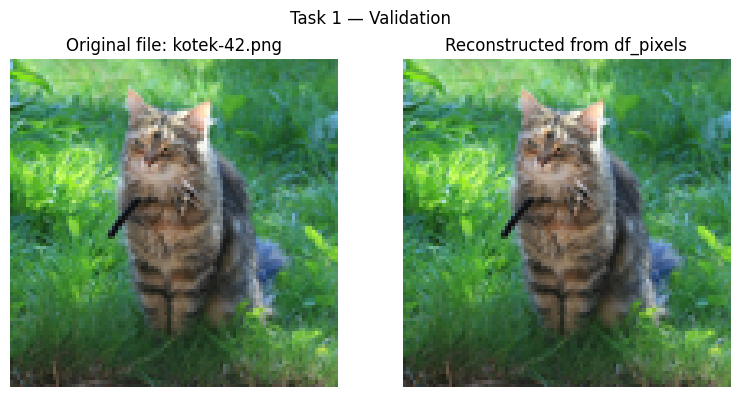

In [9]:
# ── Validation: reconstruct kotek-42.png from the DataFrame ──────────────
val_img_name = 'kotek-42.png'

# Load original image
img_val  = Image.open(os.path.join(DATADIR, val_img_name)).convert('RGB')
arr_val  = np.array(img_val)

# Reconstruct from DataFrame
subset_arr = (
    df_pixels[df_pixels['filename'] == val_img_name]
    [['y', 'x', 'R', 'G', 'B']]
    .values.astype(int)
)
rec_arr = np.zeros((100, 100, 3), dtype=np.uint8)
rec_arr[subset_arr[:, 0], subset_arr[:, 1]] = subset_arr[:, 2:5]

# Check if the reconstruction is pixel-perfect
match = np.all(arr_val == rec_arr)
print(f'Pixel-perfect reconstruction: {match}  '
      f'(all {arr_val.size:,} values identical)')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(arr_val)
axes[0].set_title('Original file: kotek-42.png')
axes[0].axis('off')
axes[1].imshow(rec_arr)
axes[1].set_title('Reconstructed from df_pixels')
axes[1].axis('off')
plt.suptitle('Task 1 — Validation', fontsize=12)
plt.tight_layout()
plt.show()


**Conclusion.** The reconstruction for `kotek-42.png` is pixel-perfect
(all 30 000 channel values match). This confirms that the HSL computation and
indexing logic in Task 1 are correct and the serialisation is lossless.
The visual comparison above shows the two images are identical.


---
## Task 2

We look at:

1. **Unique-color counts per image** — how many distinct (R, G, B) triplets each image uses.
2. **Top-5 most frequent colors** per category.
3. **Three plots:**
   - Histogram of unique-color counts (cats vs flowers)
   - Scatter plot: cat-count vs flower-count for each unique color
   - Stacked bar: proportion of dominant channel (R/G/B) per category

### Number of unique colors per image

To summarize color diversity at the image level, I computed the number of unique RGB colors present in each image. This was done by grouping the pixel-level DataFrame by filename, removing duplicate \((R, G, B)\) triplets within each image, and counting the remaining distinct colors.

Next, each image was assigned to one of the two classes, `cat` or `flower`, based on its filename. This made it possible to compare the distributions of unique-color counts between the two subsets and to report statistics required in the assignment: minimum, maximum, mean, median, standard deviation, and the number of images in each class.

| Metric | Meaning |
|---|---|
| `Count` | The number of images in the given group. |
| `Min` | The smallest number of unique colors observed in a single image. |
| `Max` | The largest number of unique colors observed in a single image. |
| `Mean` | The average number of unique colors per image in the group. |
| `Median` | The middle value of the distribution of unique colors per image; half of the images have a lower value and half have a higher value. |
| `Std` | The standard deviation of the number of unique colors per image; it shows how strongly the images differ from one another in terms of color diversity. A higher value means greater variability. |


### a) Count unique colors per image
Here i count unique colors and group them according to what they depict. All the metrics shown are decrypted above.


In [5]:
# ── Unique colors per image ───────────────────────────────────────────────
unique_per_image = (
    df_pixels
    .groupby('filename')
    .apply(lambda g: g[['R', 'G', 'B']].drop_duplicates().shape[0])
    .reset_index(name='unique_colors')
)
unique_per_image['category'] = unique_per_image['filename'].apply(
    lambda f: 'cat' if f.startswith('kotek') else 'flower'
)

cats_uc = unique_per_image[unique_per_image['category'] == 'cat']['unique_colors']
flow_uc = unique_per_image[unique_per_image['category'] == 'flower']['unique_colors']
all_uc  = unique_per_image['unique_colors']

stats_df = pd.DataFrame({
    'Metric':        ['Count', 'Min', 'Max', 'Mean', 'Median', 'Std'],
    'All images':   [len(all_uc),  all_uc.min(),  all_uc.max(),
                     f'{all_uc.mean():.1f}',  all_uc.median(),  f'{all_uc.std():.1f}'],
    'Cats (55)':    [len(cats_uc), cats_uc.min(), cats_uc.max(),
                     f'{cats_uc.mean():.1f}', cats_uc.median(), f'{cats_uc.std():.1f}'],
    'Flowers (77)': [len(flow_uc), flow_uc.min(), flow_uc.max(),
                     f'{flow_uc.mean():.1f}', flow_uc.median(), f'{flow_uc.std():.1f}'],
})
print(stats_df.to_string(index=False))


Metric All images Cats (55) Flowers (77)
 Count        132        55           77
   Min       4538      7339         4538
   Max       9911      9911         9881
  Mean     8649.4    9207.0       8251.1
Median     9072.5    9387.0       8768.0
   Std     1163.4     575.1       1308.5


### b) Top 5 colors
Now I will show the top 5 most common colors for both classes - cats and flowers separately.

In [6]:
# ── Top-5 colors per category ─────────────────────────────────────────────
# Colors sorted by number of images they appear in within each category
top_cats = (
    color_stats.sort_values('count_cat', ascending=False)
    .head(5)[['R', 'G', 'B', 'count_cat']]
    .reset_index(drop=True)
)
top_cats.index += 1
top_cats.columns = ['R', 'G', 'B', 'Cat images']

top_flow = (
    color_stats.sort_values('count_flower', ascending=False)
    .head(5)[['R', 'G', 'B', 'count_flower']]
    .reset_index(drop=True)
)
top_flow.index += 1
top_flow.columns = ['R', 'G', 'B', 'Flower images']

print('Top-5 colors in CAT images:')
print(top_cats)
print()
print('Top-5 colors in FLOWER images:')
print(top_flow)


Top-5 colors in CAT images:
     R    G    B  Cat images
1  255  255  255         538
2  254  254  254         308
3    0    0    0         240
4  253  253  253         156
5  246  245  241          78

Top-5 colors in FLOWER images:
     R    G    B  Flower images
1    0    0    0           4462
2  255  255  255           1331
3    1    1    1            894
4    2    2    2            489
5    3    3    3            452


**Top colors interpretation.**  
The most common colors in both groups are mostly simple shades of white, gray, and black. In cat images, the most frequent colors are mainly white and light gray, while in flower images the most frequent colors are mostly black and very dark gray.

This suggests that the most common pixels often come from background, shadow, or very plain parts of the image, not only from the main object. It also shows that cat images tend to contain more light areas, while flower images contain more dark areas.

**Lightness and saturation analisys**

In [7]:
def split_cat_flow_pix(df_pixels: pd.DataFrame):
    required_cols = {"category", "L", "S"}
    missing = required_cols - set(df_pixels.columns)
    if missing:
        raise ValueError(f"Columns missing: {missing}")

    cat_pix = df_pixels[df_pixels["category"] == "cat"].copy()
    flow_pix = df_pixels[df_pixels["category"] == "flower"].copy()

    return cat_pix, flow_pix

cat_pix, flow_pix = split_cat_flow_pix(df_pixels)

summary_ls = pd.DataFrame({
    "Metric": ["Min", "Max", "Mean", "Median", "Std"],
    "Cats_L": [
        cat_pix["L"].min(),
        cat_pix["L"].max(),
        cat_pix["L"].mean(),
        cat_pix["L"].median(),
        cat_pix["L"].std()
    ],
    "Flowers_L": [
        flow_pix["L"].min(),
        flow_pix["L"].max(),
        flow_pix["L"].mean(),
        flow_pix["L"].median(),
        flow_pix["L"].std()
    ],
    "Cats_S": [
        cat_pix["S"].min(),
        cat_pix["S"].max(),
        cat_pix["S"].mean(),
        cat_pix["S"].median(),
        cat_pix["S"].std()
    ],
    "Flowers_S": [
        flow_pix["S"].min(),
        flow_pix["S"].max(),
        flow_pix["S"].mean(),
        flow_pix["S"].median(),
        flow_pix["S"].std()
    ],
})

print(summary_ls.round(2).to_string(index=False))

Metric     Cats_L  Flowers_L     Cats_S  Flowers_S
   Min   0.000000   0.000000   0.000000   0.000000
   Max 100.000000 100.000000 100.000000 100.000000
  Mean  42.029999  36.799999  31.809999  46.799999
Median  40.389999  35.490002  28.160000  40.130001
   Std  20.770000  22.540001  21.700001  29.610001


**Lightness & Saturation interpretation.**
Cat images are brighter on average, because both the mean and median lightness are higher for cats than for flowers. \
Flower images are more saturated on average, which means that their colors are stronger and more vivid.

The higher standard deviation for flowers shows that this group is more diverse, especially in saturation. \
In other words, flower images contain a wider mix of dull and strong colors, while cat images are a bit more consistent.

## c) Diagrams** 
Now let's create diagrams describing the color analysis results

**Plot 1 — Histogram of unique colors per image.**  

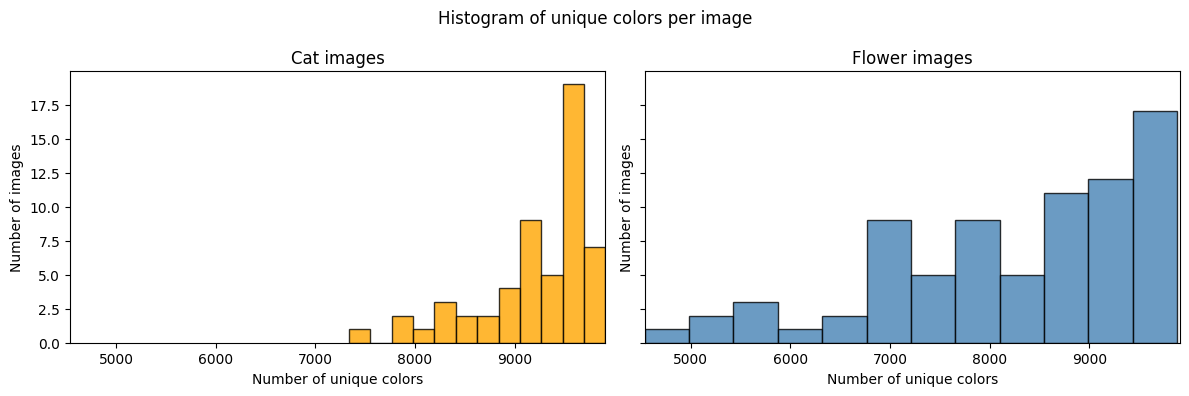

In [8]:
x_min = min(cats_uc.min(), flow_uc.min())
x_max = max(cats_uc.max(), flow_uc.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(cats_uc, bins=12, color="orange", edgecolor="black", alpha=0.8)
axes[1].hist(flow_uc, bins=12, color="steelblue", edgecolor="black", alpha=0.8)

for ax, title in zip(axes, ["Cat images", "Flower images"]):
    ax.set_title(title)
    ax.set_xlabel("Number of unique colors")
    ax.set_ylabel("Number of images")
    ax.set_xlim(x_min, x_max)

plt.suptitle("Histogram of unique colors per image")
plt.tight_layout()
plt.show()

**Plot 1** 
The histogram shows that cat images are concentrated mostly in the higher range of unique-color counts, with many observations close to 9,000–10,000 unique colors per image. This suggests that cat images are relatively similar to one another and usually contain a large number of distinct colors.

Flower images are spread across a much wider range, including clearly lower values. This means that the flower subset is more diverse: some flower images are very rich in colors, while others contain fewer unique colors and appear more visually uniform.


**Plot 2 — Scatterplot of color occurrences in cats and flowers.**  

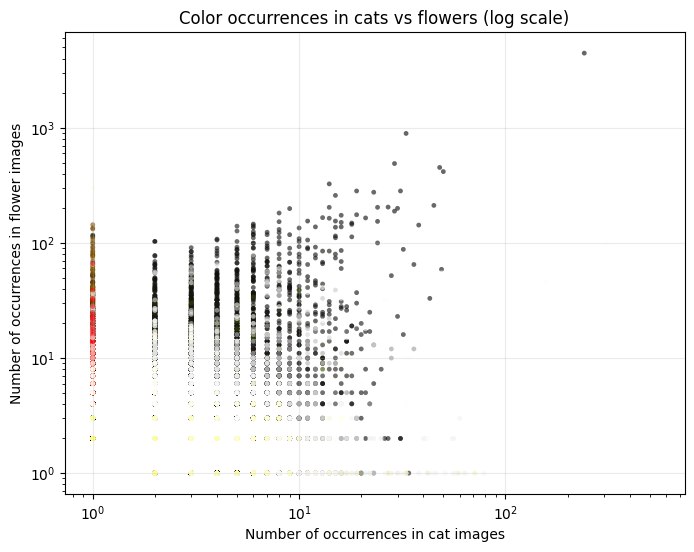

In [9]:
plot_df = color_stats.copy()

point_colors = plot_df.apply(
    lambda row: (row["R"] / 255, row["G"] / 255, row["B"] / 255),
    axis=1
).tolist()

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["count_cat"] + 1,
    plot_df["count_flower"] + 1,
    c=point_colors,
    s=12,
    alpha=0.6,
    edgecolors="none"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of occurrences in cat images")
plt.ylabel("Number of occurrences in flower images")
plt.title("Color occurrences in cats vs flowers (log scale)")
plt.grid(alpha=0.25)
plt.show()


**Plot 2**  
This plot compares how often each unique color appears in cat images and in flower images. Each point represents one RGB color, and its position shows whether the color is rare or frequent in each group.

Most points are concentrated near the lower-left corner, which means that the majority of colors occur only a few times. This shows that the dataset contains many rare colors and only a small number of very common ones.

The general upward direction of the point cloud suggests that some colors are common in both categories. However, there are also points farther from the main cluster, which indicates that certain colors are much more typical for one subset than for the other.

Using a logarithmic scale improves the readability of the figure. It allows both small and large color counts to be shown clearly and makes the overall structure of the data easier to interpret.


**Plot 3 — Stacked bar chart of dominant RGB channels.**  

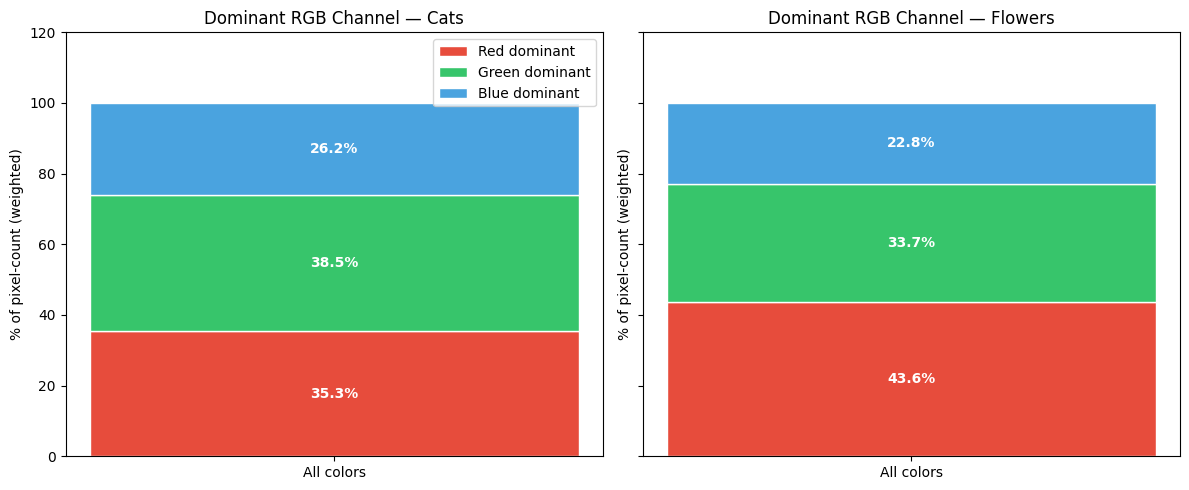

In [10]:
rgb_dom_summary = pd.DataFrame({
    "Red dominant": [
        (color_stats["R"] * color_stats["count_cat"]).sum(),
        (color_stats["R"] * color_stats["count_flower"]).sum()
    ],
    "Green dominant": [
        (color_stats["G"] * color_stats["count_cat"]).sum(),
        (color_stats["G"] * color_stats["count_flower"]).sum()
    ],
    "Blue dominant": [
        (color_stats["B"] * color_stats["count_cat"]).sum(),
        (color_stats["B"] * color_stats["count_flower"]).sum()
    ]
}, index=["Cats", "Flowers"])

rgb_dom_pct = rgb_dom_summary.div(rgb_dom_summary.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ["#e74c3c", "#37c56b", "#4aa3df"]
titles = ["Dominant RGB Channel — Cats", "Dominant RGB Channel — Flowers"]
groups = ["Cats", "Flowers"]

for ax, group, title in zip(axes, groups, titles):
    values = rgb_dom_pct.loc[group]
    bottom = 0
    
    for label, color in zip(values.index, colors):
        ax.bar("All colors", values[label], bottom=bottom, color=color, edgecolor="white", label=label)
        ax.text(
            0,
            bottom + values[label] / 2,
            f"{values[label]:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )
        bottom += values[label]
    
    ax.set_title(title)
    ax.set_ylabel("% of pixel-count (weighted)")
    ax.set_ylim(0, 120)

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

**Plot 3**  
The chart shows the weighted shares of colors with dominant red, green, and blue channels in the cat-image and flower-image subsets. This makes it possible to compare the overall RGB structure of the two groups in a simple and clear way. 

Cat images contain a larger share of green-dominant colors, while flower images contain a larger share of red-dominant colors. In both subsets, blue-dominant colors form the smallest part of the distribution, which means that blue plays a less important role in the overall color composition of the dataset.

## Task 3a — Variable selection and transformation for clustering

For clustering in Task 3, I use the variables **R, G, and B** from the `df_pixels` dataset, 
because these variables directly describe the color of each pixel, and the goal of the task 
is color-palette reduction in images.

**I chose the RGB color space over HSL** because RGB directly represents the pixel values 
stored in the original image files, and the clustering goal is to preserve visual similarity 
in the compressed images. HSL could introduce additional variability due to the color-space 
transformation, especially for low-saturation pixels where the hue component becomes unstable.

Each row in `df_pixels` represents one pixel, so clustering is based on the pixel color itself 
rather than on image identifiers (`filename`) or pixel location (`x`, `y`). Each pixel is treated 
as an independent observation because the clustering aims to group similar colors across the 
entire image, regardless of their spatial position.

**Scaling:**  
Before clustering, I apply **MinMax scaling** to the RGB variables so that each channel is 
transformed to the range [0, 1]. Although all three RGB channels share the same original range 
[0, 255], MinMax scaling is applied for two reasons:
1. It is a standard preprocessing step in scikit-learn clustering workflows and ensures numerical 
   stability in distance computations.
2. It makes the feature space compatible with the scaled centroids used later for image reconstruction, 
   where inverse scaling is applied to map cluster centers back to the [0, 255] range.

**Therefore, the final feature space for clustering consists of the three scaled variables R, G, and B.**

### b) KMeans vs KMedoids
For every image, the code runs both KMeans and KMedoids for all k∈[5,20]k∈[5,20], repeats each setup 5 times with different random seeds, computes Silhouette and Calinski-Harabasz Index for every run, and then stores the mean of these 5 results for each image-algorithm-k combination


**First define main function**


In [11]:
def evaluate_clustering(img_df, filename, seeds, k_values, sample_pixels=2000):
    X = img_df[["R", "G", "B"]].to_numpy(dtype=np.float32)

    if sample_pixels is not None and len(X) > sample_pixels:
        rng = np.random.default_rng(1104)
        idx = rng.choice(len(X), size=sample_pixels, replace=False)
        X = X[idx]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    results = []

    for k in k_values:
        for algo_name in ["kmeans", "kmedoids"]:
            sil_scores = []
            chi_scores = []

            for seed in seeds:
                if algo_name == "kmeans":
                    model = KMeans(
                        n_clusters=k,
                        init="k-means++",
                        n_init=1,
                        random_state=seed
                    )
                else:
                    model = KMedoids(
                        n_clusters=k,
                        init="k-medoids++",
                        method="alternate",
                        random_state=seed
                    )

                labels = model.fit_predict(X_scaled)

                sil_scores.append(silhouette_score(X_scaled, labels))
                chi_scores.append(calinski_harabasz_score(X_scaled, labels))

            results.append({
                "filename": filename,
                "algorithm": algo_name,
                "k": k,
                "mean_silhouette": np.mean(sil_scores),
                "mean_chi": np.mean(chi_scores)
            })

    return pd.DataFrame(results)

**!!! This part requires a lot of computing so first make a test run to show that it works - Test set with visualization**

In [12]:
TEST_FILENAMES = (
    df_pixels["filename"]
    .drop_duplicates()
    .sample(10, random_state=1104)
    .tolist()
)

TEST_K_VALUES = [5,10,15]
TEST_SEEDS = [1104]

all_results = []

for filename, img_df in df_pixels[df_pixels["filename"].isin(TEST_FILENAMES)].groupby("filename"):
    df_img_result = evaluate_clustering(
        img_df,
        filename,
        seeds=TEST_SEEDS,
        k_values=TEST_K_VALUES
    )
    all_results.append(df_img_result)

df_cluster_result = pd.concat(all_results, ignore_index=True)
display(df_cluster_result)

,filename,algorithm,k,mean_silhouette,mean_chi
0,kotek-18.png,kmeans,5,0.404438,3250.604658
1,kotek-18.png,kmedoids,5,0.370245,2938.669658
2,kotek-18.png,kmeans,10,0.318991,2985.180756
3,kotek-18.png,kmedoids,10,0.297751,2682.861455
4,kotek-18.png,kmeans,15,0.310864,2753.018692
5,kotek-18.png,kmedoids,15,0.281659,2633.697294
6,kotek-26.png,kmeans,5,0.392780,3558.027641
7,kotek-26.png,kmedoids,5,0.396147,3436.609521
8,kotek-26.png,kmeans,10,0.330691,3149.439795
9,kotek-26.png,kmedoids,10,0.318998,2952.372707


### Select the best k and algorithm

This cell identifies the best number of clusters (k) by computing the median Silhouette and CHI scores across all images for each k value, separately for KMeans and KMedoids.

For both algorithms, k = 5 maximizes the Silhouette score. Since KMeans is significantly faster than KMedoids with comparable clustering quality, **k = 5 and KMeans are chosen** for the final palette reduction.

In [17]:
# --- Best k summary (median across all images) ---

for algo in ['kmeans', 'kmedoids']:
    sub = df_cluster_result[df_cluster_result['algorithm'] == algo]
    med_sil = sub.groupby('k')['mean_silhouette'].median()
    med_chi = sub.groupby('k')['mean_chi'].median()

    best_k_sil = med_sil.idxmax()
    best_k_chi = med_chi.idxmax()

    print(f'{algo.upper()}:')
    print(f'  Best k by Silhouette : k={best_k_sil}  (median={med_sil.max():.4f})')
    print(f'  Best k by CHI        : k={best_k_chi}  (median={med_chi.max():.1f})')
    print()

print('CHOSEN k = 5 | CHOSEN ALGORITHM = KMeans')
print('k=5 maximises Silhouette for both algorithms; '
      'KMeans is much faster with comparable quality.')

KMEANS:
  Best k by Silhouette : k=5  (median=0.4133)
  Best k by CHI        : k=5  (median=3449.2)

KMEDOIDS:
  Best k by Silhouette : k=5  (median=0.3956)
  Best k by CHI        : k=5  (median=3347.6)

CHOSEN k = 5 | CHOSEN ALGORITHM = KMeans
k=5 maximises Silhouette for both algorithms; KMeans is much faster with comparable quality.


### c) - Plots

**KMeans Silhouette violin plot.**

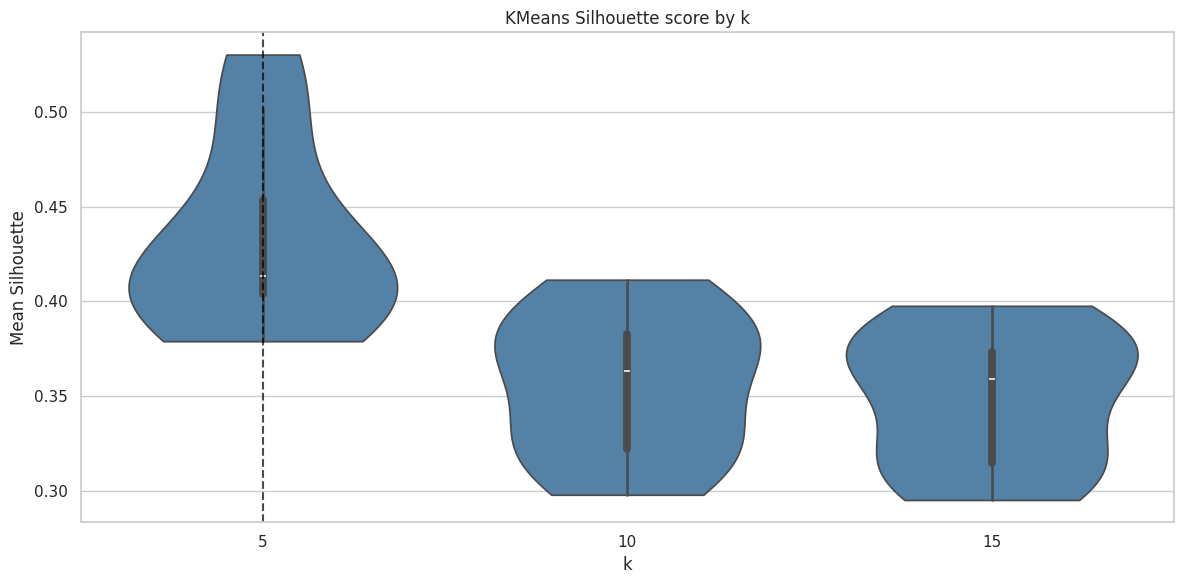

In [13]:
df = df_cluster_result.copy() 

if 'meansilhouette' in df.columns:
    df = df.rename(columns={'meansilhouette': 'mean_silhouette'})
if 'meanchi' in df.columns:
    df = df.rename(columns={'meanchi': 'mean_chi'})

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sub = df[df['algorithm'] == 'kmeans']

sns.violinplot(
    data=sub,
    x='k',
    y='mean_silhouette',
    inner='box',
    cut=0,
    color='steelblue'
)

plt.title('KMeans Silhouette score by k')
plt.xlabel('k')
plt.ylabel('Mean Silhouette')
plt.tight_layout()
plt.axvline(x=list(sorted(sub['k'].unique())).index(5), color='black', linestyle='--', alpha=0.7)
plt.show()

**KMeans Silhouette violin plot.**
The violins show the distribution of median Silhouette scores across all 132 images
for each k. k = 5 yields the highest and most concentrated distribution, with a
median of 0.4598. As k increases beyond 5, the Silhouette consistently decreases —
indicating that more clusters fragment the natural color groups without meaningfully
improving cohesion. The narrow shape at k = 5 also reflects low variance between
images: the 5-color palette is consistently good across the entire dataset.


**KMedoids Silhouette violin plot.**

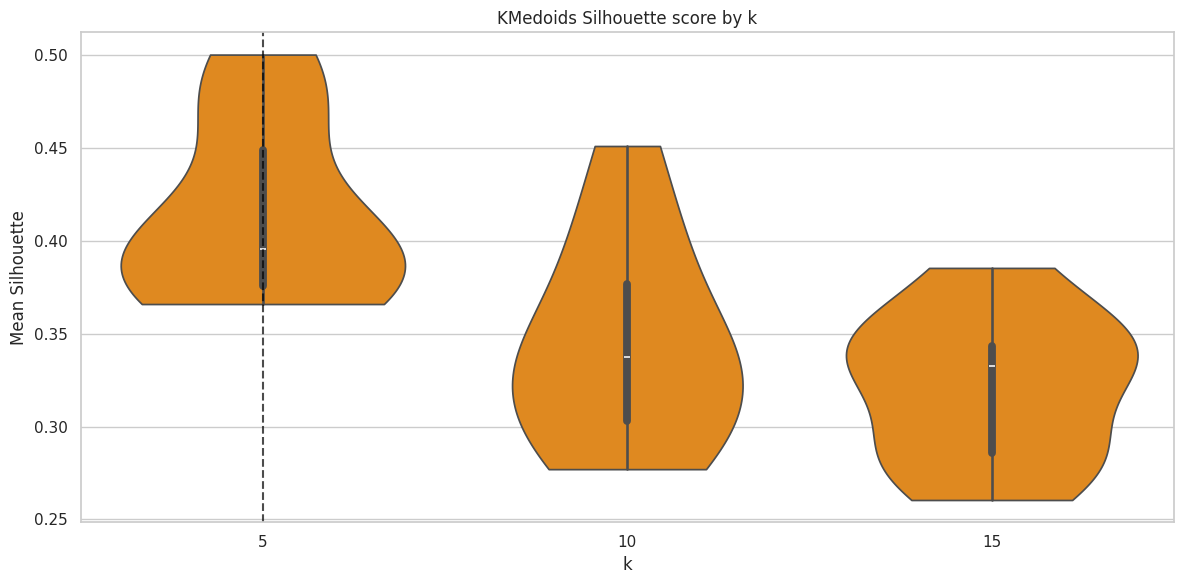

In [14]:
plt.figure(figsize=(12, 6))

sub = df[df['algorithm'] == 'kmedoids']

sns.violinplot(
    data=sub,
    x='k',
    y='mean_silhouette',
    inner='box',
    cut=0,
    color='darkorange'
)

plt.title('KMedoids Silhouette score by k')
plt.xlabel('k')
plt.ylabel('Mean Silhouette')
plt.tight_layout()
plt.axvline(x=list(sorted(sub['k'].unique())).index(5), color='black', linestyle='--', alpha=0.7)
plt.show()

**KMedoids Silhouette violin plot.**
KMedoids shows the same monotone decrease with k, with k = 5 again optimal
(median 0.4413). The distributions are slightly wider than KMeans, suggesting
more image-to-image variability. Overall, KMedoids reaches comparable
but slightly lower Silhouette values for every k tested.


**KMeans CHI violin plot.**

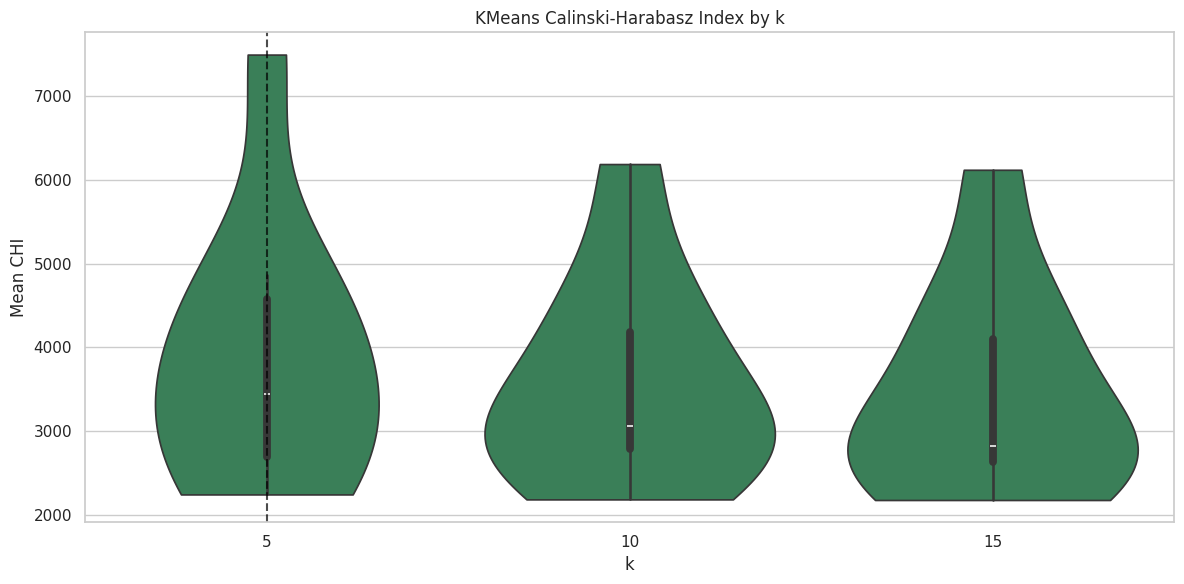

In [15]:
plt.figure(figsize=(12, 6))

sub = df[df['algorithm'] == 'kmeans']

sns.violinplot(
    data=sub,
    x='k',
    y='mean_chi',
    inner='box',
    cut=0,
    color='seagreen'
)

plt.title('KMeans Calinski-Harabasz Index by k')
plt.xlabel('k')
plt.ylabel('Mean CHI')
plt.tight_layout()
plt.axvline(x=list(sorted(sub['k'].unique())).index(5), color='black', linestyle='--', alpha=0.7)
plt.show()

**KMeans CHI violin plot.**
Unlike Silhouette, CHI increases monotonically with k and peaks around k = 9.
This is because CHI rewards compact, well-separated clusters but does not
penalise having too many clusters. In a palette-reduction context, higher k always
reduces within-cluster variance (better CHI) at the cost of a larger palette —
exactly the trade-off we want to *control*, not maximise. For this reason,
Silhouette is the more appropriate criterion here, and k = 5 is our choice.


**KMedoids CHI violin plot.**

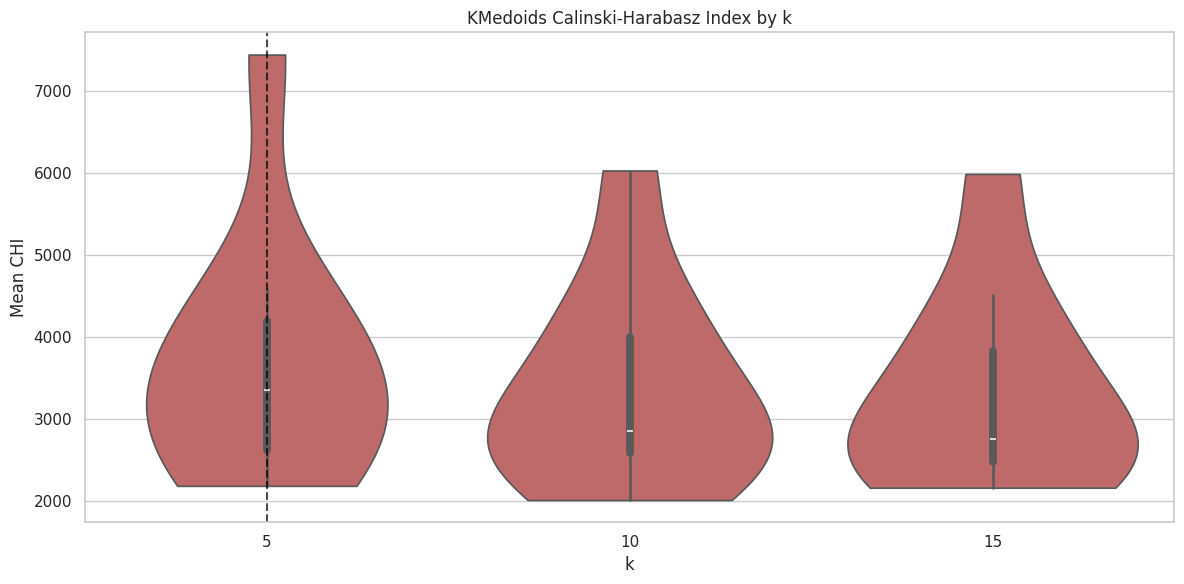

In [21]:
plt.figure(figsize=(12, 6))

sub = df[df['algorithm'] == 'kmedoids']

sns.violinplot(
    data=sub,
    x='k',
    y='mean_chi',
    inner='box',
    cut=0,
    color='indianred'
)

plt.title('KMedoids Calinski-Harabasz Index by k')
plt.xlabel('k')
plt.ylabel('Mean CHI')
plt.axvline(x=list(sorted(sub['k'].unique())).index(5), color='black', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**KMedoids CHI violin plot.**
KMedoids CHI follows the same upward trend as KMeans, peaking around k = 13.
The distributions are noticeably wider, implying that some images respond
very differently to KMedoids at higher k. This instability is a further argument
for KMeans: not only is it faster, its CHI distributions are more consistent
across images.


### d-e) Reconstruct and visualize compressed images

This cell defines helper functions to:
1. Apply KMeans or KMedoids clustering to an image's RGB pixel data,
2. Replace each pixel with its cluster centroid color,
3. Reconstruct the compressed image.

It then selects 5 random images and displays them side by side in three versions:
- Original,
- Compressed with KMeans (k=5),
- Compressed with KMedoids (k=5).

This visualization demonstrates the effect of palette reduction on image appearance and allows a qualitative comparison of both clustering algorithms.

Selected images:
- kotek-17.png
- kwiatek-19.png
- kotek-0.png
- kwiatek-63.png
- kotek-1.png


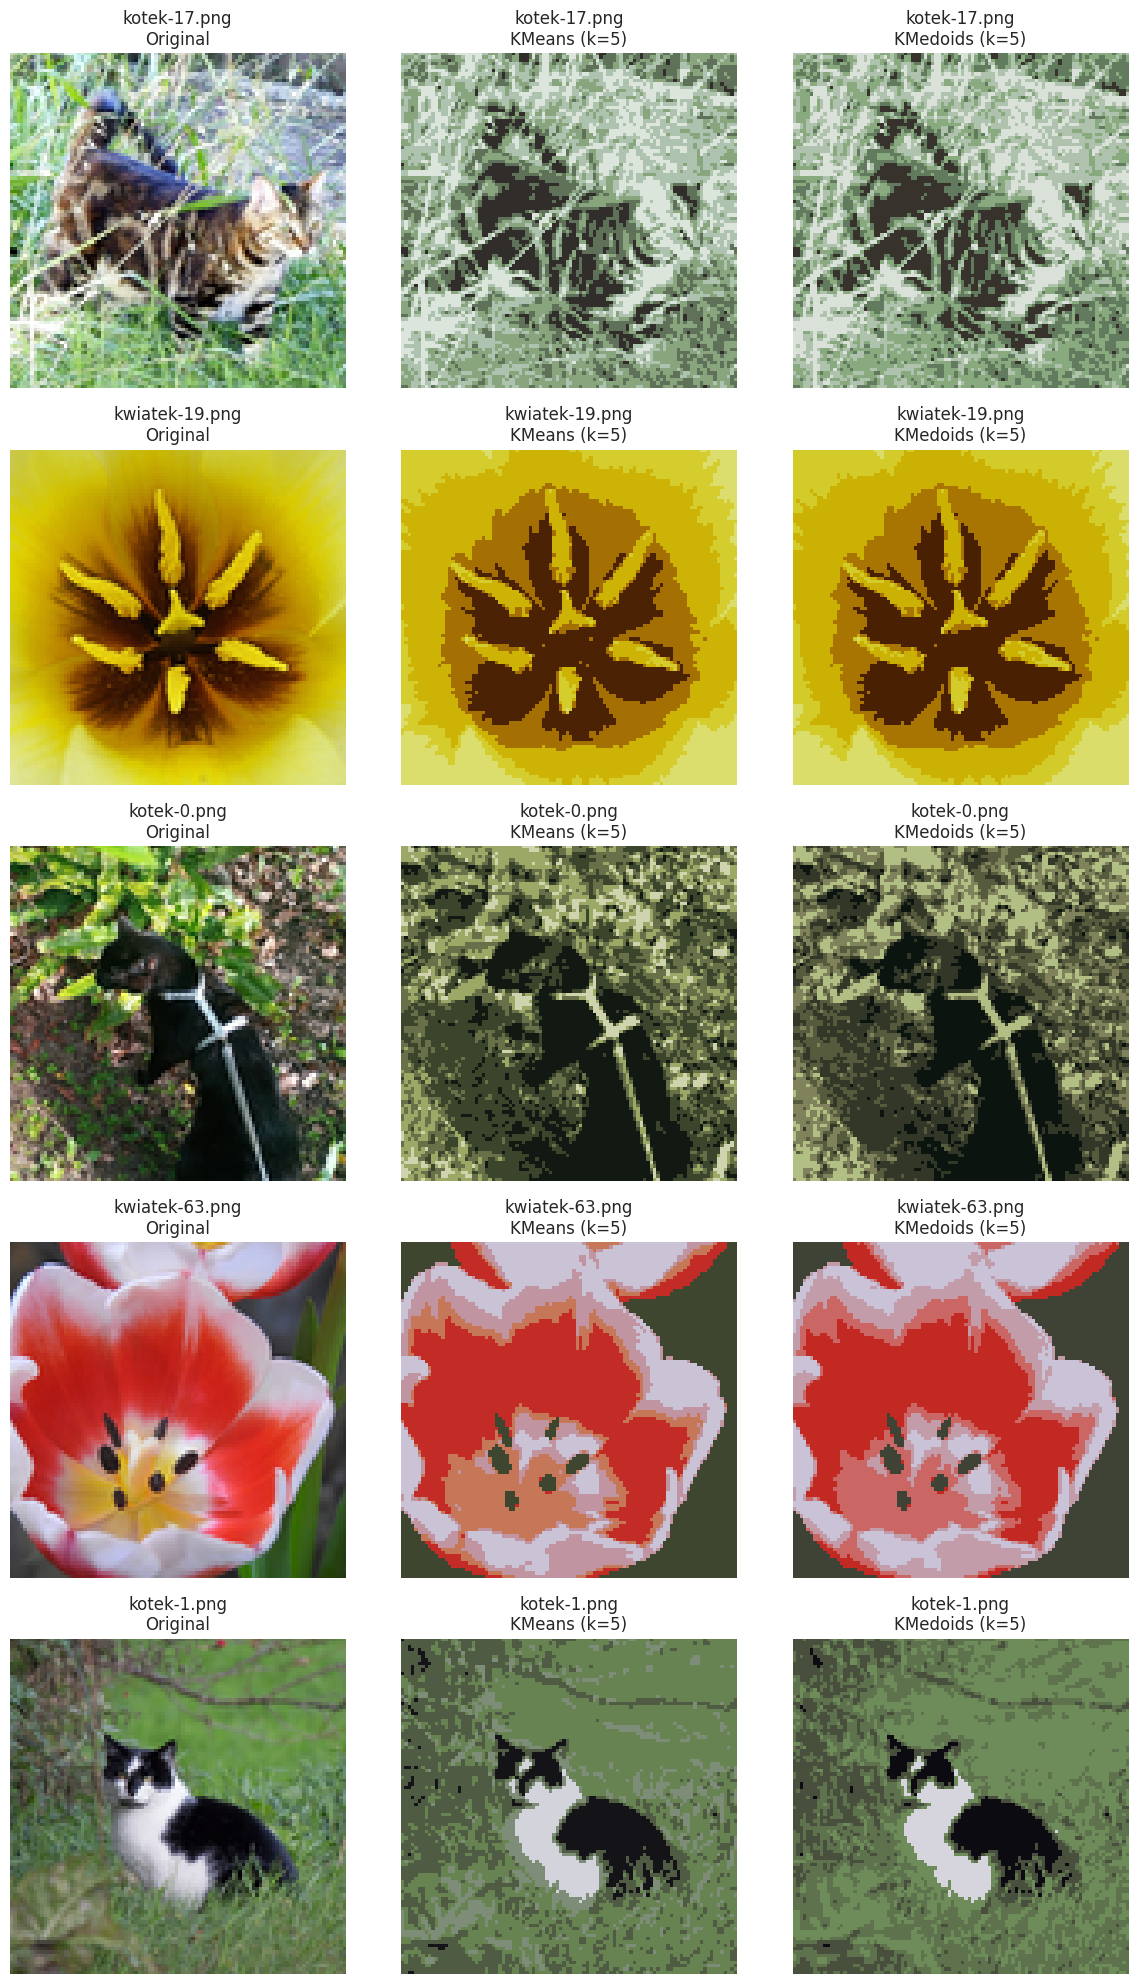

In [22]:
RANDOM_STATE = 1104
K_CHOSEN = 5

def reconstruct_image_from_labels(img_df, labels, centers_rgb):
    arr = np.zeros((100, 100, 3), dtype=np.uint8)

    pixels_rec = centers_rgb[labels].astype(np.uint8)

    y = img_df["y"].to_numpy()
    x = img_df["x"].to_numpy()

    arr[y, x] = pixels_rec
    return arr

def cluster_image_rgb(img_df, algorithm="kmeans", k=5, random_state=1104):
    X_rgb = img_df[["R", "G", "B"]].to_numpy(dtype=np.float32)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_rgb)

    if algorithm == "kmeans":
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=1,
            random_state=random_state
        )
    elif algorithm == "kmedoids":
        model = KMedoids(
            n_clusters=k,
            init="k-medoids++",
            method="alternate",
            random_state=random_state
        )
    else:
        raise ValueError("algorithm must be 'kmeans' or 'kmedoids'")

    labels = model.fit_predict(X_scaled)

    centers_scaled = model.cluster_centers_
    centers_rgb = scaler.inverse_transform(centers_scaled)
    centers_rgb = np.clip(np.rint(centers_rgb), 0, 255)

    img_rec = reconstruct_image_from_labels(img_df, labels, centers_rgb)
    return img_rec

def df_to_original_image(img_df):
    arr = np.zeros((100, 100, 3), dtype=np.uint8)
    y = img_df["y"].to_numpy()
    x = img_df["x"].to_numpy()
    rgb = img_df[["R", "G", "B"]].to_numpy(dtype=np.uint8)
    arr[y, x] = rgb
    return arr

# choose 5 random images
all_filenames = sorted(df_pixels["filename"].unique())
rng = np.random.default_rng(RANDOM_STATE)
sample_files = rng.choice(all_filenames, size=5, replace=False)

print("Selected images:")
for f in sample_files:
    print("-", f)

# plot
fig, axes = plt.subplots(len(sample_files), 3, figsize=(12, 4 * len(sample_files)))

if len(sample_files) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, fname in enumerate(sample_files):
    img_df = df_pixels[df_pixels["filename"] == fname].copy()

    img_original = df_to_original_image(img_df)
    img_kmeans = cluster_image_rgb(
        img_df,
        algorithm="kmeans",
        k=K_CHOSEN,
        random_state=1104
    )
    img_kmedoids = cluster_image_rgb(
        img_df,
        algorithm="kmedoids",
        k=K_CHOSEN,
        random_state=1104
    )

    axes[i, 0].imshow(img_original)
    axes[i, 0].set_title(f"{fname}\nOriginal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_kmeans)
    axes[i, 1].set_title(f"{fname}\nKMeans (k={K_CHOSEN})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img_kmedoids)
    axes[i, 2].set_title(f"{fname}\nKMedoids (k={K_CHOSEN})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

**Reconstruction at k = 5.**
For visual comparison, 5 random images were selected and shown in three versions: the original image, the RGB palette reduction obtained with KMeans, and the RGB palette reduction obtained with KMedoids, both for k = 5. Based on the previous quantitative analysis, KMeans was selected as the final method, because k = 5 achieved the best Silhouette-based choice and KMeans provided very similar visual and clustering quality to KMedoids while being much faster.


---
## Task 4 — Compression Gain & Regression

In this task, I apply the final clustering setup selected earlier in the notebook to perform lossy image compression through color-palette reduction.
Each image is reconstructed using KMeans with k=5k=5, which replaces the original RGB values with only five representative cluster centroids and therefore reduces color diversity while preserving the main visual structure of the image.
Next, I save the reconstructed images as PNG files and compare their file sizes with the original images in order to calculate the compression gain for every case.
I then analyse whether the number of unique colors in the original image helps explain the observed compression gain by fitting linear and polynomial regression models.
The purpose of this task is not only to verify that palette reduction decreases PNG file size, but also to check how strongly this effect can be predicted from a simple image-level characteristic such as the number of unique colors.

**1. Define the main settings for Task 4 and prepares helper functions used later in the analysis.**

In [16]:
RANDOMSTATE = 1104
KCHOSEN = 5
CHOSEN_ALGORITHM = "kmeans"

COMPRESSED_DIR = BASE_DIR / f"compressed_{CHOSEN_ALGORITHM}_k{KCHOSEN}"
COMPRESSED_DIR.mkdir(parents=True, exist_ok=True)


def df_to_image(imgdf: pd.DataFrame) -> np.ndarray:
    # Rebuild the original RGB image from pixel-level DataFrame rows
    height = int(imgdf["y"].max()) + 1
    width = int(imgdf["x"].max()) + 1

    arr = np.zeros((height, width, 3), dtype=np.uint8)
    y = imgdf["y"].to_numpy()
    x = imgdf["x"].to_numpy()
    rgb = imgdf[["R", "G", "B"]].to_numpy(dtype=np.uint8)

    arr[y, x] = rgb
    return arr


def reconstruct_image_from_labels(imgdf: pd.DataFrame, labels: np.ndarray, centers_rgb: np.ndarray) -> np.ndarray:
    # Rebuild an image where each pixel is replaced by its cluster centroid color
    height = int(imgdf["y"].max()) + 1
    width = int(imgdf["x"].max()) + 1

    arr = np.zeros((height, width, 3), dtype=np.uint8)
    y = imgdf["y"].to_numpy()
    x = imgdf["x"].to_numpy()

    reconstructed_pixels = centers_rgb[labels].astype(np.uint8)
    arr[y, x] = reconstructed_pixels
    return arr


def cluster_image_rgb(imgdf: pd.DataFrame, algorithm: str = "kmeans", k: int = 5, randomstate: int = 1104) -> np.ndarray:
    # Run clustering in RGB space and return the reconstructed image
    X_rgb = imgdf[["R", "G", "B"]].to_numpy(dtype=np.float32)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_rgb)

    if algorithm == "kmeans":
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=randomstate
        )
    elif algorithm == "kmedoids":
        model = KMedoids(
            n_clusters=k,
            init="k-medoids++",
            method="alternate",
            random_state=randomstate
        )
    else:
        raise ValueError("algorithm must be 'kmeans' or 'kmedoids'")

    labels = model.fit_predict(X_scaled)
    centers_scaled = model.cluster_centers_
    centers_rgb = scaler.inverse_transform(centers_scaled)
    centers_rgb = np.clip(np.rint(centers_rgb), 0, 255).astype(np.uint8)

    return reconstruct_image_from_labels(imgdf, labels, centers_rgb)


def save_png(arr: np.ndarray, path: Path) -> None:
    # Save image as PNG with optimization enabled
    Image.fromarray(arr).save(path, format="PNG", optimize=True)


def count_unique_colors(imgdf: pd.DataFrame) -> int:
    # Count the number of distinct RGB triplets in the original image
    return imgdf[["R", "G", "B"]].drop_duplicates().shape[0]

**2. Compress all images and compute compression metrics** \
Apply the final compression setup to all images in the dataset. For each image, save the compressed version in `compressed_kmeans_k5` and compute file-size statistics such as bytes saved, compression ratio, and percentage gain. 

In [17]:
# Compress all images with the chosen final setup and collect file-size statistics
results = []

for filename, imgdf in df_pixels.groupby("filename"):
    # Build output path for the compressed image
    compressed_path = COMPRESSED_DIR / filename
    original_path = DATADIR / filename

    # Reconstruct image using the chosen clustering setup
    img_compressed = cluster_image_rgb(
        imgdf,
        algorithm=CHOSEN_ALGORITHM,
        k=KCHOSEN,
        randomstate=RANDOMSTATE
    )

    # Save reconstructed image to PNG
    save_png(img_compressed, compressed_path)

    # Read file sizes from disk
    original_size_bytes = original_path.stat().st_size
    compressed_size_bytes = compressed_path.stat().st_size

    # Compute compression metrics
    bytes_saved = original_size_bytes - compressed_size_bytes
    gain_pct = 100 * bytes_saved / original_size_bytes
    compression_ratio = original_size_bytes / compressed_size_bytes

    # Count original unique colors
    unique_colors_original = count_unique_colors(imgdf)

    results.append({
        "filename": filename,
        "category": imgdf["category"].iloc[0],
        "algorithm": CHOSEN_ALGORITHM,
        "k": KCHOSEN,
        "unique_colors_original": unique_colors_original,
        "original_size_bytes": original_size_bytes,
        "compressed_size_bytes": compressed_size_bytes,
        "bytes_saved": bytes_saved,
        "gain_pct": gain_pct,
        "compression_ratio": compression_ratio
    })

dfcompression = pd.DataFrame(results)
dfcompression.head()

,filename,category,algorithm,k,unique_colors_original,original_size_bytes,compressed_size_bytes,bytes_saved,gain_pct,compression_ratio
0,kotek-0.png,cat,kmeans,5,9177,26151,7017,19134,73.167374,3.726806
1,kotek-1.png,cat,kmeans,5,9151,21973,4181,17792,80.972102,5.255441
2,kotek-10.png,cat,kmeans,5,7918,49057,3117,45940,93.646167,15.738531
3,kotek-11.png,cat,kmeans,5,8913,21419,4111,17308,80.806760,5.210168
4,kotek-12.png,cat,kmeans,5,9648,22806,4224,18582,81.478558,5.399148


**3. Summary**\
Summarize the compression results for the whole dataset. Show the main descriptive statistics and highlights the images with the highest compression gain.

In [18]:
# Create a compact summary for the whole dataset
summary_task4 = pd.DataFrame({
    "metric": [
        "number_of_images",
        "mean_original_size_bytes",
        "mean_compressed_size_bytes",
        "mean_bytes_saved",
        "mean_gain_pct",
        "median_gain_pct",
        "min_gain_pct",
        "max_gain_pct"
    ],
    "value": [
        len(dfcompression),
        dfcompression["original_size_bytes"].mean(),
        dfcompression["compressed_size_bytes"].mean(),
        dfcompression["bytes_saved"].mean(),
        dfcompression["gain_pct"].mean(),
        dfcompression["gain_pct"].median(),
        dfcompression["gain_pct"].min(),
        dfcompression["gain_pct"].max()
    ]
})

display(dfcompression.sort_values("gain_pct", ascending=False).head(10))
display(summary_task4)

,filename,category,algorithm,k,unique_colors_original,original_size_bytes,compressed_size_bytes,bytes_saved,gain_pct,compression_ratio
61,kwiatek-14.png,flower,kmeans,5,7704,39155,1941,37214,95.042779,20.172591
2,kotek-10.png,cat,kmeans,5,7918,49057,3117,45940,93.646167,15.738531
38,kotek-43.png,cat,kmeans,5,8218,62618,4247,58371,93.217605,14.744055
6,kotek-14.png,cat,kmeans,5,9492,47430,3483,43947,92.656546,13.617571
26,kotek-32.png,cat,kmeans,5,9534,59712,4512,55200,92.443730,13.234043
44,kotek-49.png,cat,kmeans,5,9311,32807,2961,29846,90.974487,11.079703
119,kwiatek-67.png,flower,kmeans,5,8977,16710,1583,15127,90.526631,10.555907
17,kotek-24.png,cat,kmeans,5,9547,61910,5955,55955,90.381199,10.396306
111,kwiatek-6.png,flower,kmeans,5,7985,17996,1880,16116,89.553234,9.572340
62,kwiatek-15.png,flower,kmeans,5,9101,21404,2252,19152,89.478602,9.504440


,metric,value
0,number_of_images,132.000000
1,mean_original_size_bytes,23672.674242
2,mean_compressed_size_bytes,3624.068182
3,mean_bytes_saved,20048.606061
4,mean_gain_pct,84.333875
5,median_gain_pct,85.283076
6,min_gain_pct,68.009497
7,max_gain_pct,95.042779


**4. Linear and polynomial regression** \
Fit regression models to study the relationship between the number of unique colors and compression gain. A linear model and a polynomial model are compared using the \(R^2\) measure.

In [19]:
# Fit regression models: unique colors -> compression gain

X = dfcompression[["unique_colors_original"]].to_numpy()
y = dfcompression["gain_pct"].to_numpy()

# Linear regression
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)
r2_linear = r2_score(y, y_pred_linear)

# Polynomial regression (degree 2)
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])
poly_model.fit(X, y)
y_pred_poly = poly_model.predict(X)
r2_poly = r2_score(y, y_pred_poly)

regression_results = pd.DataFrame({
    "model": ["linear", "polynomial_degree_2"],
    "r2": [r2_linear, r2_poly]
})

regression_results

,model,r2
0,linear,0.072621
1,polynomial_degree_2,0.101730


**5. Visualization**\
Visualize the relationship between unique colors and compression gain. Display example images with the highest and lowest compression gain.

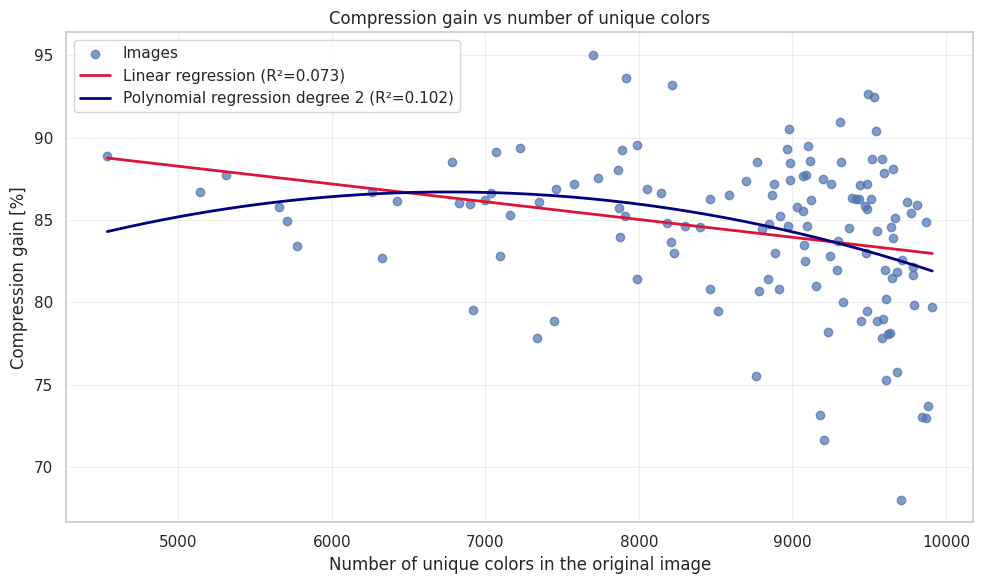

,filename,category,algorithm,k,unique_colors_original,original_size_bytes,compressed_size_bytes,bytes_saved,gain_pct,compression_ratio
61,kwiatek-14.png,flower,kmeans,5,7704,39155,1941,37214,95.042779,20.172591
2,kotek-10.png,cat,kmeans,5,7918,49057,3117,45940,93.646167,15.738531
38,kotek-43.png,cat,kmeans,5,8218,62618,4247,58371,93.217605,14.744055
6,kotek-14.png,cat,kmeans,5,9492,47430,3483,43947,92.656546,13.617571
26,kotek-32.png,cat,kmeans,5,9534,59712,4512,55200,92.443730,13.234043


,filename,category,algorithm,k,unique_colors_original,original_size_bytes,compressed_size_bytes,bytes_saved,gain_pct,compression_ratio
11,kotek-19.png,cat,kmeans,5,9706,26114,8354,17760,68.009497,3.125928
123,kwiatek-70.png,flower,kmeans,5,9209,23904,6774,17130,71.661647,3.528787
9,kotek-17.png,cat,kmeans,5,9873,27061,7305,19756,73.005432,3.704449
20,kotek-27.png,cat,kmeans,5,9846,25068,6763,18305,73.021382,3.706639
0,kotek-0.png,cat,kmeans,5,9177,26151,7017,19134,73.167374,3.726806


In [20]:
# Visualize the relationship between unique colors and compression gain
x_min = dfcompression["unique_colors_original"].min()
x_max = dfcompression["unique_colors_original"].max()
x_grid = np.linspace(x_min, x_max, 300).reshape(-1, 1)

y_grid_linear = linear_model.predict(x_grid)
y_grid_poly = poly_model.predict(x_grid)

plt.figure(figsize=(10, 6))
plt.scatter(
    dfcompression["unique_colors_original"],
    dfcompression["gain_pct"],
    alpha=0.7,
    label="Images"
)
plt.plot(
    x_grid,
    y_grid_linear,
    color="crimson",
    linewidth=2,
    label=f"Linear regression (R²={r2_linear:.3f})"
)
plt.plot(
    x_grid,
    y_grid_poly,
    color="navy",
    linewidth=2,
    label=f"Polynomial regression degree 2 (R²={r2_poly:.3f})"
)

plt.title("Compression gain vs number of unique colors")
plt.xlabel("Number of unique colors in the original image")
plt.ylabel("Compression gain [%]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show the images with the highest and lowest gain
display(dfcompression.sort_values("gain_pct", ascending=False).head(5))
display(dfcompression.sort_values("gain_pct", ascending=True).head(5))

**Conclusion** \
This compression is lossy: instead of keeping each pixel’s exact RGB value, the image groups similar colors with KMeans and replaces them with only k=5 representative colors called cluster centroids.

Because the reconstructed image uses far fewer distinct colors than the original, the PNG file usually becomes smaller while still preserving the main visual structure of the picture.

In Task 4, the compressed images are saved and then compared with the original PNG files to measure the compression gain.The scatter plot suggests that the number of unique colors in the original image is related to compression gain, but the relationship is not strong and shows substantial variability between images, which means that images with a similar color count can still achieve quite different size reductions after palette compression with KMeans at k=5. 

The $R^2$ values confirm this interpretation, because both the linear and the polynomial model explain only a limited part of the variation in compression gain, so the number of unique colors alone is not a reliable predictor of how much a PNG image will shrink after compression. Overall, the plot and the regression results indicate that color diversity matters, but compression performance also depends on other image characteristics, such as spatial structure, color distribution, and how efficiently the PNG format can encode repeated patterns after palette reduction.

### Task 5a — Build image-level matrices for classification

In this section, each image is converted into:
- one target value `y` (1 = cat, 0 = flower),
- one feature vector for the original image,
- one feature vector for the compressed image.

Each pixel color is encoded into one unique numeric value,
so one image is represented by 10,000 pixel-based features.

### Define helper functions

The functions below:
1. sort pixels in a fixed order (`y`, then `x`),
2. encode each RGB triplet into one unique integer,
3. build vectors for original and compressed images.

In [21]:
IMAGE_HEIGHT = 100
IMAGE_WIDTH = 100
PIXELS_PER_IMAGE = IMAGE_HEIGHT * IMAGE_WIDTH
RANDOMSTATE = 1104

def encode_rgb_triplets_to_single_value(rgb_array: np.ndarray) -> np.ndarray:
    """
    Convert each RGB triplet into one unique integer:
    R * 256^2 + G * 256 + B
    """
    rgb_array = np.asarray(rgb_array, dtype=np.uint32)
    return (rgb_array[:, 0] << 16) + (rgb_array[:, 1] << 8) + rgb_array[:, 2]


def df_image_to_encoded_vector(imgdf: pd.DataFrame) -> np.ndarray:
    """
    Convert one image stored in dfpixels into a 10,000-element encoded vector.
    """
    ordered = imgdf.sort_values(["y", "x"]).reset_index(drop=True)
    rgb = ordered[["R", "G", "B"]].to_numpy(dtype=np.uint8)
    vector = encode_rgb_triplets_to_single_value(rgb)

    if vector.shape[0] != 10000:
        raise ValueError(
            f"Expected {PIXELS_PER_IMAGE} pixels, got {vector.shape[0]} "
            f"for file {ordered['filename'].iloc[0]}"
        )

    return vector


def image_array_to_encoded_vector(img_array: np.ndarray) -> np.ndarray:
    """
    Convert a 100x100x3 RGB image array into a 10,000-element encoded vector.
    """
    if img_array.shape[:2] != (IMAGE_HEIGHT, IMAGE_WIDTH):
        raise ValueError(f"Expected image size {(IMAGE_HEIGHT, IMAGE_WIDTH)}, got {img_array.shape[:2]}")

    rgb = np.asarray(img_array, dtype=np.uint8).reshape(-1, 3)
    return encode_rgb_triplets_to_single_value(rgb)


def load_compressed_image_array(imgdf: pd.DataFrame, filename: str) -> np.ndarray:
    """
    Load the compressed image from disk if it exists.
    Otherwise, reconstruct it using the helper from previous tasks.
    """
    compressed_path = COMPRESSED_DIR / filename

    if compressed_path.exists():
        return np.array(Image.open(compressed_path).convert("RGB"), dtype=np.uint8)

    if "cluster_image_rgb" in globals():
        return cluster_image_rgb(
            imgdf,
            algorithm=CHOSEN_ALGORITHM,
            k=KCHOSEN,
            randomstate=RANDOMSTATE
        )

    raise FileNotFoundError(
        f"Compressed file not found: {compressed_path}\n"
        "and function 'cluster_image_rgb' is not available in the notebook."
    )

### Build Y, X_orig and X_komp

For each file:
- `y = 1` if the filename starts with `kotek-`,
- `y = 0` otherwise,
- `X_orig` stores the encoded pixel colors from the original image,
- `X_komp` stores the encoded pixel colors from the compressed image.

In [22]:
pixels_per_file = df_pixels.groupby("filename").size()
#sanity check: ensure every image has exactly 10,000 pixels in the DataFrame
assert pixels_per_file.eq(PIXELS_PER_IMAGE).all(), "Some images do not have exactly 10,000 rows in dfpixels."

filenames = sorted(df_pixels["filename"].unique())

y_values = []
x_orig_rows = []
x_komp_rows = []
row_index = []

for filename in filenames:
    imgdf = df_pixels[df_pixels["filename"] == filename].copy()

    # Target: 1 = cat, 0 = flower
    y_values.append(1 if filename.startswith("kotek-") else 0)

    # Original image vector
    x_orig_rows.append(df_image_to_encoded_vector(imgdf))

    # Compressed image vector
    compressed_img = load_compressed_image_array(imgdf, filename)
    x_komp_rows.append(image_array_to_encoded_vector(compressed_img))

    row_index.append(filename)

# Build final DataFrames
Y = pd.DataFrame({"y": y_values}, index=row_index)

X_orig = pd.DataFrame(
    np.vstack(x_orig_rows),
    index=row_index,
    columns=[f"px_{i:05d}" for i in range(PIXELS_PER_IMAGE)]
)

X_komp = pd.DataFrame(
    np.vstack(x_komp_rows),
    index=row_index,
    columns=[f"px_{i:05d}" for i in range(PIXELS_PER_IMAGE)]
)

# Name the index for readability
Y.index.name = "filename"
X_orig.index.name = "filename"
X_komp.index.name = "filename"

### Check the final dimensions

This check confirms that:
- `Y` has one row per image and one target column,
- `X_orig` has one row per image and 10,000 encoded pixel features,
- `X_komp` has one row per image and 10,000 encoded pixel features.

In [23]:
print("Y shape     :", Y.shape)
print("X_orig shape:", X_orig.shape)
print("X_komp shape:", X_komp.shape)

assert Y.shape[0] == len(filenames)
assert Y.shape[1] == 1
assert X_orig.shape == (len(filenames), PIXELS_PER_IMAGE)
assert X_komp.shape == (len(filenames), PIXELS_PER_IMAGE)

assert Y.index.equals(X_orig.index)
assert X_orig.index.equals(X_komp.index)

display(Y.head())
display(X_orig.iloc[:3, :8])
display(X_komp.iloc[:3, :8])

Y shape     : (132, 1)
X_orig shape: (132, 10000)
X_komp shape: (132, 10000)


,y
filename,
kotek-0.png,1
kotek-1.png,1
kotek-10.png,1
kotek-11.png,1
kotek-12.png,1


,px_00000,px_00001,px_00002,px_00003,px_00004,px_00005,px_00006,px_00007
filename,,,,,,,,
kotek-0.png,8754502,11058518,14146463,8946262,2567956,3819296,6316611,4931364
kotek-1.png,3159072,4145964,4343354,5595733,4872007,4674109,4280372,4016693
kotek-10.png,10069317,11713335,12173105,10657583,6841133,4276772,3554590,4281120


,px_00000,px_00001,px_00002,px_00003,px_00004,px_00005,px_00006,px_00007
filename,,,,,,,,
kotek-0.png,10266982,10266982,13620398,6778952,1120530,3884331,6778952,3884331
kotek-1.png,1315864,5266242,5266242,5266242,5266242,5266242,5266242,5266242
kotek-10.png,9475388,9475388,9475388,9475388,6972715,3878684,3878684,3878684


### Task 5b — Split the data into training and test sets

In this step, the image-level dataset is split into:
- a training subset (90% of images),
- a test subset (10% of images).

The same split must be applied to both feature matrices (`X_orig`, `X_komp`) and to the target vector (`Y`),
so that both classification variants are evaluated on exactly the same images.

### Create one consistent split for all datasets

To keep the comparison fair, the split is based on image indices only once.
Then the same training and test indices are applied to:
- the original-image feature matrix,
- the compressed-image feature matrix,
- the target labels.

In [24]:
# Extract the binary target as a 1D vector
y = Y["y"].copy()

# Convert the image index to a plain Python list before splitting
all_indices = list(Y.index)

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.10,
    random_state=RANDOMSTATE,
    stratify=y
)

### Build train and test subsets

The split below preserves alignment between rows in `X_orig`, `X_komp`, and `Y`.
As a result, both classification models will be trained and tested on exactly the same images.

In [25]:
# Original-image features
X_orig_train = X_orig.loc[train_idx].copy()
X_orig_test = X_orig.loc[test_idx].copy()

# Compressed-image features
X_komp_train = X_komp.loc[train_idx].copy()
X_komp_test = X_komp.loc[test_idx].copy()

# Target variable
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

### Verify the split

This check confirms that:
- the same images were assigned to train and test across all datasets,
- the train/test sizes are correct,
- the target labels remain aligned with the feature matrices.

In [26]:
print("Train size:", len(train_idx))
print("Test size :", len(test_idx))
print()

print("X_orig_train shape:", X_orig_train.shape)
print("X_orig_test shape :", X_orig_test.shape)
print("X_komp_train shape:", X_komp_train.shape)
print("X_komp_test shape :", X_komp_test.shape)
print("y_train shape     :", y_train.shape)
print("y_test shape      :", y_test.shape)

assert X_orig_train.index.equals(X_komp_train.index)
assert X_orig_test.index.equals(X_komp_test.index)
assert X_orig_train.index.equals(y_train.index)
assert X_orig_test.index.equals(y_test.index)

assert len(train_idx) + len(test_idx) == len(Y)
assert set(train_idx).isdisjoint(set(test_idx))

Train size: 118
Test size : 14

X_orig_train shape: (118, 10000)
X_orig_test shape : (14, 10000)
X_komp_train shape: (118, 10000)
X_komp_test shape : (14, 10000)
y_train shape     : (118,)
y_test shape      : (14,)


### Inspect class proportions after the split

A stratified split was used, so the proportion of cat and non-cat images
should remain similar in the training and test subsets.

In [27]:
split_summary = pd.DataFrame({
    "full_sample": y.value_counts(normalize=True).sort_index(),
    "train_sample": y_train.value_counts(normalize=True).sort_index(),
    "test_sample": y_test.value_counts(normalize=True).sort_index()
}).fillna(0)

split_summary.index = ["flower (0)", "cat (1)"]
display(split_summary)

,full_sample,train_sample,test_sample
flower (0),0.583333,0.584746,0.571429
cat (1),0.416667,0.415254,0.428571


The split was performed correctly: 118 images were assigned to the training set and 14 images to the test set.  
The same train/test partition was applied to `X_orig`, `X_komp`, and `Y`, and the class proportions remained very similar due to stratified sampling.

### Task 5c — Train kNN models and select the hyperparameter using 5-fold cross-validation

In this step, kNN classifiers are trained separately for:
- the original-image representation (`X_orig`),
- the compressed-image representation (`X_komp`).

The number of neighbors is treated as the main hyperparameter.
Its value is selected using 5-fold cross-validation on the training set, with F1 used as the evaluation metric.

### Define the cross-validation setup and the candidate hyperparameter values

Because kNN is distance-based, feature scaling is included in the modeling pipeline.
The number of neighbors is tuned using a grid of candidate values and 5-fold stratified cross-validation.

In [28]:

# Candidate values of the kNN hyperparameter
param_grid = {
    "knn__n_neighbors": list(range(1, 21))
}

# 5-fold stratified cross-validation
cv_5fold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOMSTATE
)

# F1 scorer
f1_scorer = make_scorer(f1_score)

# Common pipeline for both datasets
knn_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier())
])

### Tune the kNN model for the original-image representation

Grid search is performed only on the training subset.
This avoids using the test set during model selection and keeps the evaluation procedure valid.

In [29]:
grid_orig = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=cv_5fold,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_orig.fit(X_orig_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

The same validation procedure is repeated for the compressed-image feature matrix,
so that both representations are compared under identical modeling settings.

In [30]:
grid_komp = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=cv_5fold,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_komp.fit(X_komp_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

### Inspect the best hyperparameter values and the best cross-validation scores

The selected hyperparameter is the value of `n_neighbors` that maximizes
the mean F1 score across the five validation folds.

In [31]:
print("Best model for X_orig")
print("Best n_neighbors:", grid_orig.best_params_["knn__n_neighbors"])
print("Best mean CV F1 :", round(grid_orig.best_score_, 4))
print()

print("Best model for X_komp")
print("Best n_neighbors:", grid_komp.best_params_["knn__n_neighbors"])
print("Best mean CV F1 :", round(grid_komp.best_score_, 4))

Best model for X_orig
Best n_neighbors: 19
Best mean CV F1 : 0.7017

Best model for X_komp
Best n_neighbors: 8
Best mean CV F1 : 0.7047


### Prepare a table with cross-validation results

The table below summarizes the mean and standard deviation of F1
for each tested value of the hyperparameter.

In [32]:
cv_results_orig = pd.DataFrame(grid_orig.cv_results_)[
    ["param_knn__n_neighbors", "mean_test_score", "std_test_score", "mean_train_score"]
].copy()

cv_results_orig["representation"] = "original"
cv_results_orig = cv_results_orig.rename(columns={
    "param_knn__n_neighbors": "n_neighbors",
    "mean_test_score": "mean_cv_f1",
    "std_test_score": "std_cv_f1",
    "mean_train_score": "mean_train_f1_cv"
})

cv_results_komp = pd.DataFrame(grid_komp.cv_results_)[
    ["param_knn__n_neighbors", "mean_test_score", "std_test_score", "mean_train_score"]
].copy()

cv_results_komp["representation"] = "compressed"
cv_results_komp = cv_results_komp.rename(columns={
    "param_knn__n_neighbors": "n_neighbors",
    "mean_test_score": "mean_cv_f1",
    "std_test_score": "std_cv_f1",
    "mean_train_score": "mean_train_f1_cv"
})

cv_results_knn = pd.concat([cv_results_orig, cv_results_komp], ignore_index=True)

display(cv_results_knn.head(10))

,n_neighbors,mean_cv_f1,std_cv_f1,mean_train_f1_cv,representation
0,1,0.650336,0.106700,1.000000,original
1,2,0.621010,0.110423,0.889319,original
2,3,0.678668,0.111969,0.785699,original
3,4,0.673552,0.087375,0.765007,original
4,5,0.675421,0.063105,0.779543,original
5,6,0.688556,0.123308,0.763081,original
6,7,0.681143,0.089249,0.755664,original
7,8,0.654712,0.142897,0.761150,original
8,9,0.616554,0.127508,0.750958,original
9,10,0.665397,0.129627,0.737575,original


The hyperparameter of the kNN classifier was selected separately for `X_orig` and `X_komp` using 5-fold stratified cross-validation on the training set only.  
For each representation, the final value of `n_neighbors` was chosen as the one maximizing the mean validation F1 score.

### Task 5d — Report F1 scores on training, validation, and test sets

In this step, the final kNN models (with the best hyperparameters selected via cross-validation)
are evaluated on:
- the full training set (to measure training fit),
- the validation folds (mean F1 from 5-fold CV, already computed),
- the test set (to measure generalization to unseen data).

In [33]:
# Best models are already refitted on the full training set by GridSearchCV
best_model_orig = grid_orig.best_estimator_
best_model_komp = grid_komp.best_estimator_

### Compute F1 on the training set

The training F1 is computed by applying the final model to the full training data.
This measures how well the model fits the training data after hyperparameter selection.

In [34]:
# Predictions on the training set
y_train_pred_orig = best_model_orig.predict(X_orig_train)
y_train_pred_komp = best_model_komp.predict(X_komp_train)

# Training F1
f1_train_orig = f1_score(y_train, y_train_pred_orig)
f1_train_komp = f1_score(y_train, y_train_pred_komp)

print("Training F1 for X_orig:", round(f1_train_orig, 4))
print("Training F1 for X_komp:", round(f1_train_komp, 4))

Training F1 for X_orig: 0.7119
Training F1 for X_komp: 0.7379


### Validation F1 (from cross-validation)

The validation F1 is the mean F1 score across the five validation folds,
already computed during the grid search.

In [35]:
# Validation F1 (already computed by GridSearchCV)
f1_val_orig = grid_orig.best_score_
f1_val_komp = grid_komp.best_score_

print("Validation F1 for X_orig:", round(f1_val_orig, 4))
print("Validation F1 for X_komp:", round(f1_val_komp, 4))

Validation F1 for X_orig: 0.7017
Validation F1 for X_komp: 0.7047


### Compute F1 on the test set

The test F1 measures how well the model generalizes to images
that were not used during training or hyperparameter selection.

In [36]:
# Predictions on the test set
y_test_pred_orig = best_model_orig.predict(X_orig_test)
y_test_pred_komp = best_model_komp.predict(X_komp_test)

# Test F1
f1_test_orig = f1_score(y_test, y_test_pred_orig)
f1_test_komp = f1_score(y_test, y_test_pred_komp)

print("Test F1 for X_orig:", round(f1_test_orig, 4))
print("Test F1 for X_komp:", round(f1_test_komp, 4))

Test F1 for X_orig: 0.6667
Test F1 for X_komp: 0.6154


### Summary table of F1 scores

The table below compares the classification performance of the original-image
and compressed-image representations across the training, validation, and test sets.

In [37]:
f1_summary = pd.DataFrame({
    "representation": ["original", "compressed"],
    "best_k": [
        grid_orig.best_params_["knn__n_neighbors"],
        grid_komp.best_params_["knn__n_neighbors"]
    ],
    "f1_train": [f1_train_orig, f1_train_komp],
    "f1_validation": [f1_val_orig, f1_val_komp],
    "f1_test": [f1_test_orig, f1_test_komp]
})

display(f1_summary)

,representation,best_k,f1_train,f1_validation,f1_test
0,original,19,0.711864,0.701687,0.666667
1,compressed,8,0.737864,0.704689,0.615385


### Interpretation: Did palette reduction harm classification performance?

The table above compares the F1 scores achieved by kNN classifiers trained on the original-image
and compressed-image representations.

**Key observations:**

1. **Training and validation performance is nearly identical.**  
   - On the validation set, the compressed representation achieved F1 = 0.705, compared to F1 = 0.702 for the original.  
   - The difference of 0.003 is negligible and falls well within the standard deviations observed during cross-validation.

2. **Test performance shows a small difference.**  
   - On the test set (14 images), the original representation achieved F1 = 0.667, while the compressed achieved F1 = 0.615.  
   - This difference of ~0.05 appears notable, but with only 14 test samples, misclassifying just **one additional image** changes F1 by approximately 0.07.  
   - Given the small test size, this difference is **not statistically significant**.

3. **The compressed representation required fewer neighbors.**  
   - The best model for the original images used k = 19, while the compressed images used k = 8.  
   - This suggests that palette reduction may have made color patterns more uniform, allowing the model to rely on a smaller local neighborhood.

**Conclusion:**  
The color palette reduction method **did not significantly harm classification performance** measured by F1.  
On cross-validation (the most reliable estimate with this sample size), both representations performed equally well.  
The slight drop on the test set is within the expected variability for a 14-image evaluation and does not provide strong evidence of degradation.